In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/paprikaryash/datasets-1/datasets/VA.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/AZ.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/LA.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/CO.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/MO.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/CT.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/NM.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/ID.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/AL.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/GA.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/MS.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/NY.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/DE.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/WI.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets/MD.TXT
/kaggle/input/datasets/paprikaryash/datasets-1/datasets

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = Path("/kaggle/input/datasets/paprikaryash/datasets-1/datasets")
files = sorted(DATA_DIR.glob("*.TXT"))
print("files:", len(files))

df = pd.concat(
    (
        pd.read_csv(
            f,
            header=None,
            names=["state", "sex", "year", "name", "count"],
        )
        for f in files
    ),
    ignore_index=True,
)

print(df.shape)
df.head()

files: 51
(6311504, 5)


,state,sex,year,name,count
0,AK,F,1910,Mary,14
1,AK,F,1910,Annie,12
2,AK,F,1910,Anna,10
3,AK,F,1910,Margaret,8
4,AK,F,1910,Helen,7


In [ ]:
# Cell 3 — A1 checks

In [6]:
print("years:", int(df["year"].min()), "→", int(df["year"].max()))
print("n_states:", df["state"].nunique())
print("states:", ", ".join(sorted(df["state"].unique())))

years: 1910 → 2021
n_states: 51
states: AK, AL, AR, AZ, CA, CO, CT, DC, DE, FL, GA, HI, IA, ID, IL, IN, KS, KY, LA, MA, MD, ME, MI, MN, MO, MS, MT, NC, ND, NE, NH, NJ, NM, NV, NY, OH, OK, OR, PA, RI, SC, SD, TN, TX, UT, VA, VT, WA, WI, WV, WY


In [7]:
print("sexes:", df["sex"].unique().tolist())

sexes: ['F', 'M']


In [8]:
print("min count:", int(df["count"].min()))

min count: 5


In [9]:
print("max name len:", df["name"].str.len().max())

max name len: 15


In [10]:
print("nulls:\n", df.isna().sum())

nulls:
 state    0
sex      0
year     0
name     0
count    0
dtype: int64


In [11]:
print("dup keys:", int(df.duplicated(["state", "sex", "year", "name"]).sum()))

dup keys: 0


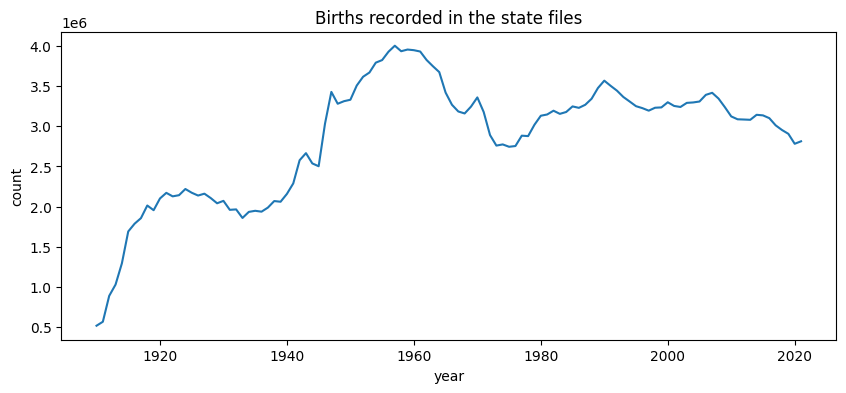

sex
F    153512251
M    166219447
Name: count, dtype: int64

In [14]:
births_by_year = df.groupby("year")["count"].sum()
ax = births_by_year.plot(title="Births recorded in the state files")
ax.set_ylabel("count")
plt.show()

df.groupby("sex")["count"].sum()

In [15]:
# A2 — most popular name of all time (either gender)
by_name = (
    df.groupby("name")["count"]
    .sum()
    .sort_values(ascending=False)
)

In [16]:
print("Most popular name of all time:")
print(by_name.head(1))
print("\nTop 10 overall:")
display(by_name.head(10).to_frame("total_count"))

Most popular name of all time:
name
James    5054074
Name: count, dtype: int64

Top 10 overall:


,total_count
name,
James,5054074
John,4910976
Robert,4763102
Michael,4396482
William,3939912
Mary,3757625
David,3631489
Joseph,2554530
Richard,2550606


In [17]:
top5_f = (
    df[df["sex"] == "F"]   # use "gender" if that is your column
    .groupby("name")["count"].sum()
    .sort_values(ascending=False)
    .head(5)
)

In [18]:
top5_m = (
    df[df["sex"] == "M"]
    .groupby("name")["count"].sum()
    .sort_values(ascending=False)
    .head(5)
)

In [19]:
print("\nTop 5 female:")
display(top5_f.to_frame("total_count"))
print("Top 5 male:")
display(top5_m.to_frame("total_count"))


Top 5 female:


,total_count
name,
Mary,3747982
Patricia,1569661
Elizabeth,1560365
Jennifer,1468240
Linda,1448868


Top 5 male:


,total_count
name,
James,5035762
John,4895305
Robert,4747986
Michael,4379257
William,3929698


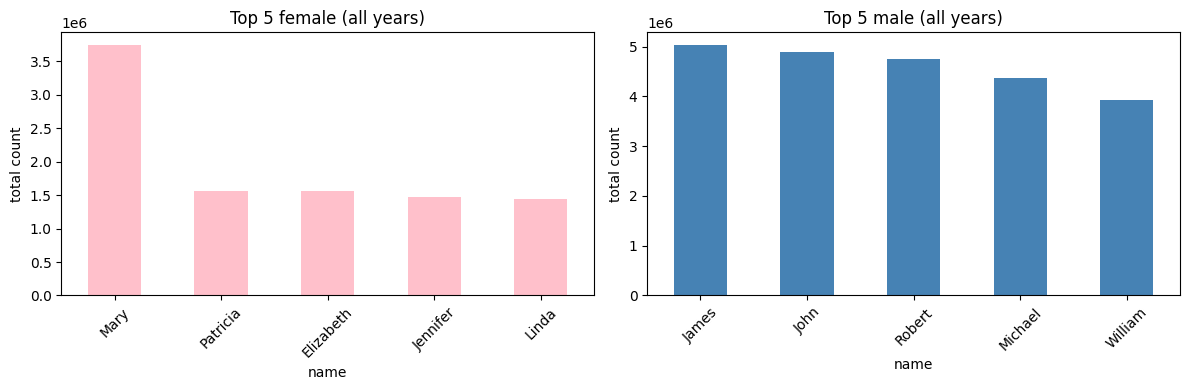

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
top5_f.plot(kind="bar", ax=axes[0], color="pink", title="Top 5 female (all years)")
top5_m.plot(kind="bar", ax=axes[1], color="steelblue", title="Top 5 male (all years)")
for ax in axes:
    ax.set_ylabel("total count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Most popular name of all time, summing counts across states, years, and sexes: James. This is a longevity result (decades near the top for boys), not a current-trend result. Mary leads among girls.

In [22]:
# A3 — most gender-ambiguous name in 2013 and 1945
def gender_ambiguous(df, year, min_total=50):
    y = (
        df.loc[df["year"] == year]
        .groupby(["name", "sex"])["count"]
        .sum()
        .unstack(fill_value=0)
    )
    y = y[(y["M"] > 0) & (y["F"] > 0)].copy()
    y["total"] = y["M"] + y["F"]
    y["ratio"] = y[["M", "F"]].min(axis=1) / y[["M", "F"]].max(axis=1)
    y = y[y["total"] >= min_total]
    return y.sort_values(["ratio", "total"], ascending=[False, False])

amb_2013 = gender_ambiguous(df, 2013)
amb_1945 = gender_ambiguous(df, 1945)

print("2013 — most ambiguous (min 50 births)")
display(amb_2013.head(10))
print("1945 — most ambiguous (min 50 births)")
display(amb_1945.head(10))

2013 — most ambiguous (min 50 births)


sex,F,M,total,ratio
name,,,,
Nikita,47,47,94,1.000000
Jael,129,130,259,0.992308
Milan,430,451,881,0.953437
Jaidyn,85,90,175,0.944444
Aven,81,87,168,0.931034
Arie,33,36,69,0.916667
Reilly,59,54,113,0.915254
Britton,32,36,68,0.888889
Lennon,224,253,477,0.885375


1945 — most ambiguous (min 50 births)


sex,F,M,total,ratio
name,,,,
Lavern,70,74,144,0.945946
Frankie,482,548,1030,0.879562
Leslie,1679,1975,3654,0.850127
Jessie,1072,909,1981,0.847948
Jackie,1246,1472,2718,0.846467
Leigh,28,39,67,0.717949
Marlyn,32,22,54,0.687500
Gerry,159,236,395,0.673729
Toby,106,71,177,0.669811


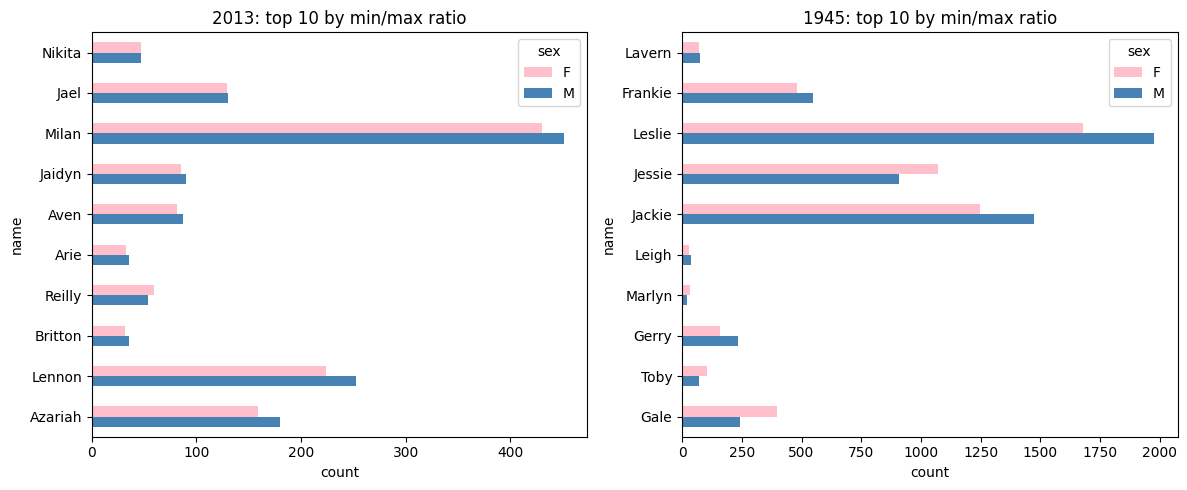

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tbl, yr in [(axes[0], amb_2013, 2013), (axes[1], amb_1945, 1945)]:
    top = tbl.head(10)[["F", "M"]]
    top.plot(kind="barh", ax=ax, color=["pink", "steelblue"])
    ax.set_title(f"{yr}: top 10 by min/max ratio")
    ax.set_xlabel("count")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [24]:
print("2013 with NO minimum (privacy-floor names)")
display(gender_ambiguous(df, 2013, min_total=0).head(5))

2013 with NO minimum (privacy-floor names)


sex,F,M,total,ratio
name,,,,
Nikita,47,47,94,1.0
Cree,11,11,22,1.0
Devine,10,10,20,1.0
Arlin,5,5,10,1.0
Sonam,5,5,10,1.0


Ambiguity = min(M, F) / max(M, F). 1.0 = even split.
Dropped names with fewer than 50 births that year so Sonam 5/5 cannot win.
Headline answers are row 1 of each table.

# A4 next


In [29]:
def window_share(df, years):
    w = df[df["year"].isin(years)]
    nat = w.groupby(["year", "name"])["count"].sum()
    year_total = nat.groupby(level="year").transform("sum")
    return (nat / year_total).groupby("name").mean()

old = window_share(df, range(1980, 1985))
new = window_share(df, range(2017, 2022))

chg = pd.DataFrame({"share_1980s": old, "share_recent": new}).dropna()
chg = chg[chg["share_1980s"] >= chg["share_1980s"].quantile(0.50)]
chg["pct_change"] = (chg["share_recent"] - chg["share_1980s"]) / chg["share_1980s"]

up = chg.sort_values("pct_change", ascending=False)
down = chg.sort_values("pct_change")

print("Largest increases")
display(up.head(10))
print("Largest decreases")
display(down.head(10))

Largest increases


,share_1980s,share_recent,pct_change
name,,,
Grayson,0.000008,0.002817,332.012231
Penelope,0.000009,0.002236,240.814707
Asher,0.000010,0.002503,238.794968
Liam,0.000029,0.006881,236.626202
Ava,0.000023,0.004930,217.349789
Gianna,0.000009,0.001771,189.648514
Carter,0.000019,0.003134,164.374517
Lincoln,0.000016,0.002578,160.786621
Kennedy,0.000008,0.001304,152.437011


Largest decreases


,share_1980s,share_recent,pct_change
name,,,
Jill,0.001062,0.000002,-0.998382
Misty,0.001290,0.000003,-0.997670
Kristi,0.000662,0.000002,-0.997491
Kristin,0.002564,0.000007,-0.997365
Kelli,0.000711,0.000002,-0.996862
Michele,0.000669,0.000002,-0.996710
Brandi,0.001628,0.000005,-0.996694
Brandy,0.001851,0.000006,-0.996683
Ebony,0.000611,0.000002,-0.996640


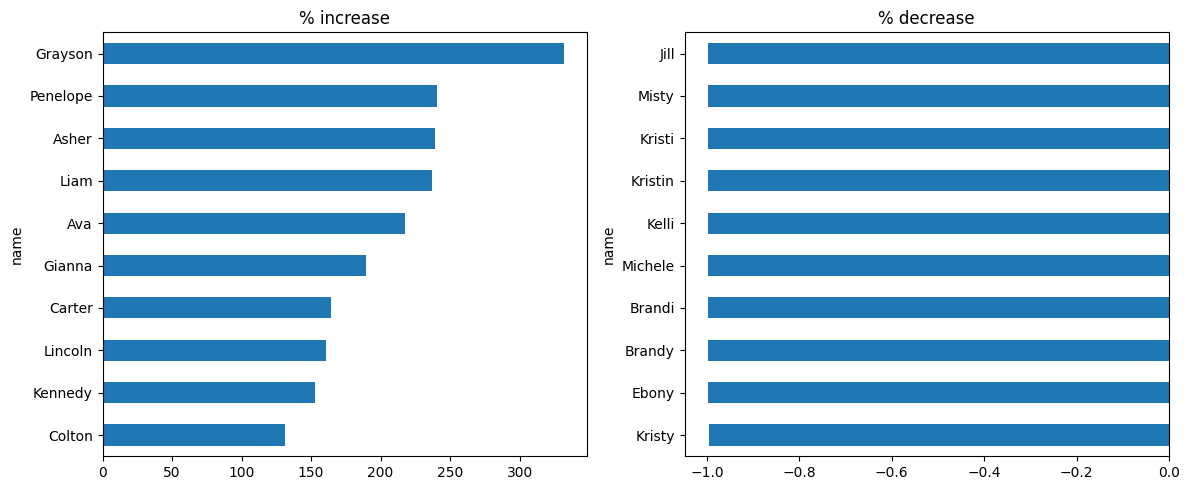

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
up.head(10)["pct_change"].iloc[::-1].plot(kind="barh", ax=axes[0], title="% increase")
down.head(10)["pct_change"].iloc[::-1].plot(kind="barh", ax=axes[1], title="% decrease")
plt.tight_layout()
plt.show()

In [ ]:
# A5
# This cell is only “who did A4 leave out.”

In [31]:
# A5 — swings A4 could not score
debuts = new.index.difference(old.index)
gone = old.index.difference(new.index)

debut_counts = (
    df[df["name"].isin(debuts) & df["year"].between(2017, 2021)]
    .groupby("name")["count"].sum()
    .sort_values(ascending=False)
)

gone_1980s = old.loc[gone].sort_values(ascending=False)

print("Big recent names with no 1980–84 record (increase is undefined / infinite)")
display(debut_counts.head(15).to_frame("count_2017_21"))

print("Names present in 1980–84 and absent in 2017–21 (decrease hidden by the 5-count cutoff)")
display(gone_1980s.head(15).to_frame("share_1980s"))

Big recent names with no 1980–84 record (increase is undefined / infinite)


,count_2017_21
name,
Harper,49505
Aiden,47597
Jayden,40845
Jaxon,34510
Maverick,28269
Zoey,28185
Sawyer,24635
Paisley,22148
Jaxson,21913


Names present in 1980–84 and absent in 2017–21 (decrease hidden by the 5-count cutoff)


,share_1980s
name,
Latoya,0.001143
Tonya,0.000759
Tasha,0.000610
Latasha,0.000580
Sheena,0.000562
Shawna,0.000462
Shanna,0.000390
Rhonda,0.000359
Tamika,0.000327


## metric = change in mean birth-share, 1980–84 vs 2017–21
### winners = Grayson / Jill
### recognizable cousins = Liam, Ava / Kristin, Jennifer-class names
### bigger moves exist among debuts and extinct names

In [ ]:
# Part B — next cell
# One insight: names used for both sexes, then a few trajectories.

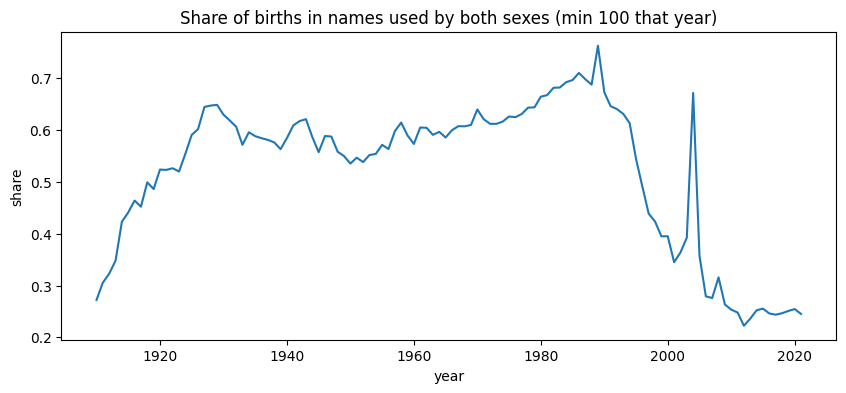

In [32]:
# B — share of births in names used by both sexes
def yearly_unisex(df, min_total=100):
    g = (
        df.groupby(["year", "name", "sex"])["count"]
        .sum()
        .unstack(fill_value=0)
    )
    g["total"] = g["M"] + g["F"]
    g = g[(g["M"] > 0) & (g["F"] > 0) & (g["total"] >= min_total)].copy()
    g["ratio"] = g[["M", "F"]].min(axis=1) / g[["M", "F"]].max(axis=1)
    return g.reset_index()

ua = yearly_unisex(df)
all_births = df.groupby("year")["count"].sum()
unisex_births = ua.groupby("year")["total"].sum()
share = (unisex_births / all_births).rename("unisex_share")

share.plot(title="Share of births in names used by both sexes (min 100 that year)")
plt.ylabel("share")
plt.show()

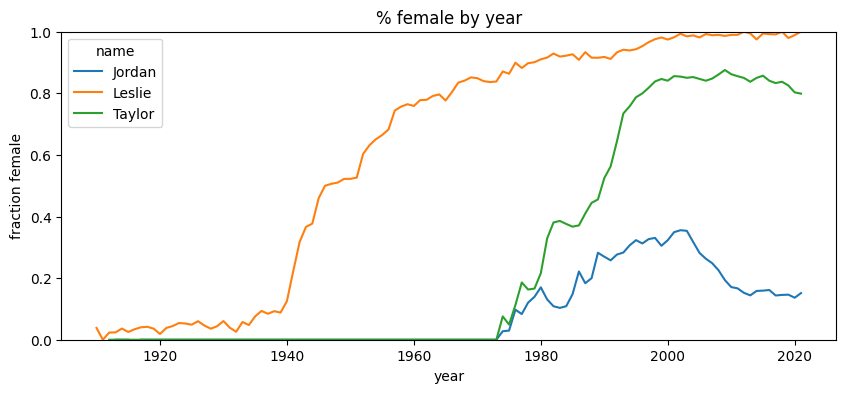

In [33]:
def pct_female(df, names):
    s = (
        df[df["name"].isin(names)]
        .groupby(["year", "name", "sex"])["count"]
        .sum()
        .unstack(fill_value=0)
    )
    s["pct_f"] = s["F"] / (s["F"] + s["M"])
    return s["pct_f"].unstack("name")

traj = pct_female(df, ["Taylor", "Jordan", "Leslie"])
traj.plot(title="% female by year")
plt.ylabel("fraction female")
plt.ylim(0, 1)
plt.show()

## Unisex volume and unisex balance are different. Many “unisex” names drift female and stay there (Taylor, Leslie).
## That matches A3: 1945 unisex names are Frankie / Leslie / Jessie; 2013 names are Nikita / Milan / Lennon — different inventory, not the same names getting more balanced.
### Tie to A5: Harper / Sawyer / River are new unisex-ish names that did not exist in the 1980 file.

#,Question,Answer,

How it was defined
## @A1,Format / limits,"51 files, state,sex,year,name,count, 1910–2021, 6.31M rows, min count 5",No header; privacy floor; SSN coverage weak before ~1937; spellings are separate names; raw count ≠ popularity
## A2,Most popular all-time,"James (5,054,074)","groupby(""name"")[""count""].sum() across all states/years/sexes. Mary leads girls"
A3,Ambiguous 2013,"Nikita (47 F / 47 M, ratio 1.00)","min(M,F)/max(M,F), both sexes, total ≥ 50. Runners-up: Jael, Milan"
A3,Ambiguous 1945,"Lavern (70 F / 74 M, ratio 0.95)","Same rule. Runners-up: Frankie, Leslie (higher volume)"
### A4,Largest % increase since 1980,"Grayson (~+33,200%)","Mean birth-share, 1980–84 vs 2017–21; name in both windows; drop bottom half of 1980s shares. Liam / Ava are the recognizable version"
A4,Largest % decrease,Jill (~−99.8%),Same metric. Kristin / Misty same pattern. 80s peak names collapsed
A5,Even larger swings,"Up: Harper, Aiden, Jayden, Jaxon, Maverick (no 1980–84 row → % undefined). Down: Latoya, Tonya, Tasha, Sheena (present in 1980s, absent 2017–21)",A4 cannot score debuts or names wiped out by the 5-count floor

## Step,Methods
## Load 51 files,"Path.glob / glob.glob, pd.read_csv(..., header=None, names=...), pd.concat(..., ignore_index=True)"
## Quality,".shape, .nunique(), .min()/.max(), .isna().sum(), .duplicated(), groupby(""year"")[""count""].sum(), .plot()"
## A2,"groupby(""name"")[""count""].sum(), .sort_values(ascending=False), .head(), boolean filter df[df[""sex""]==""F""]"
## A3,".loc[df[""year""]==y], groupby([""name"",""sex""])[""count""].sum(), .unstack(fill_value=0), column math, .sort_values([""ratio"",""total""])"
## A4,"filter isin(range(...)), groupby([""year"",""name""])[""count""].sum(), .groupby(level=""year"").transform(""sum"") for shares, pd.DataFrame({...}).dropna(), .quantile(0.50), vectorized % change, .sort_values"
## A5,"Index.difference, .between(2017,2021), .isin(...)"
B,"same unstack as A3 by year, divide by yearly totals, .unstack(""name"") for trajectories"